# Project 2:Student Performance Prediction 

In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import warnings 
warnings.filterwarnings("ignore")


In [5]:
data={"StudentID":[101,102,103,104,105,106,107,108,109],
      "Attendance":[95,80,85,10,75,90,65,99,99],
      "StudyHours":[10,9,8,7,6,5,4,3,2],
      "PreviousScore":[90,88,77,66,55,77,66,88,99],
      "Assingmenta":[3,4,5,6,7,6,7,5,6],
      "SleepHours":[8,5,6,7,5,4,6,6,7,],
      "InternetHours":[2,3,4,4,5,6,7,8,7],
      "Extraclasses":["yes","No","yes","No","yes","no","no","yes","no"],
      "familySupport":["high","medium","high","low","high","low","high","medium","low"],
      "Marks":[90,80,78,98,67,76,98,77,88]
      }
df=pd.DataFrame(data)
print(df)

   StudentID  Attendance  StudyHours  PreviousScore  Assingmenta  SleepHours  \
0        101          95          10             90            3           8   
1        102          80           9             88            4           5   
2        103          85           8             77            5           6   
3        104          10           7             66            6           7   
4        105          75           6             55            7           5   
5        106          90           5             77            6           4   
6        107          65           4             66            7           6   
7        108          99           3             88            5           6   
8        109          99           2             99            6           7   

   InternetHours Extraclasses familySupport  Marks  
0              2          yes          high     90  
1              3           No        medium     80  
2              4          yes          h

# Explore the data

In [6]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   StudentID  Attendance  StudyHours  PreviousScore  Assingmenta  SleepHours  \
0        101          95          10             90            3           8   
1        102          80           9             88            4           5   
2        103          85           8             77            5           6   
3        104          10           7             66            6           7   
4        105          75           6             55            7           5   

   InternetHours Extraclasses familySupport  Marks  
0              2          yes          high     90  
1              3           No        medium     80  
2              4          yes          high     78  
3              4           No           low     98  
4              5          yes          high     67  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID

# Data cleaning 

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns 

In [9]:
le=LabelEncoder()
df["Extraclasses"]=le.fit_transform(df["Extraclasses"])
df["familySupport"]=le.fit_transform(df["familySupport"])

## Exploratory Data analysis 

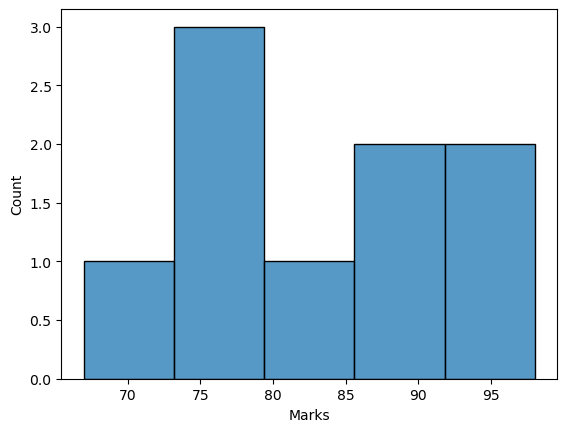

In [10]:
sns.histplot(df["Marks"])
plt.show()

In [11]:
print(df.columns)

Index(['StudentID', 'Attendance', 'StudyHours', 'PreviousScore', 'Assingmenta',
       'SleepHours', 'InternetHours', 'Extraclasses', 'familySupport',
       'Marks'],
      dtype='object')


## Attendance Vs Marks

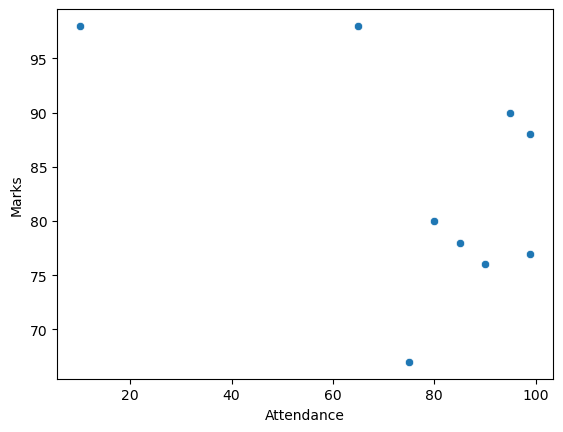

In [12]:
sns.scatterplot(x="Attendance",y="Marks",data=df)
plt.show()

## correleation using heatmap 

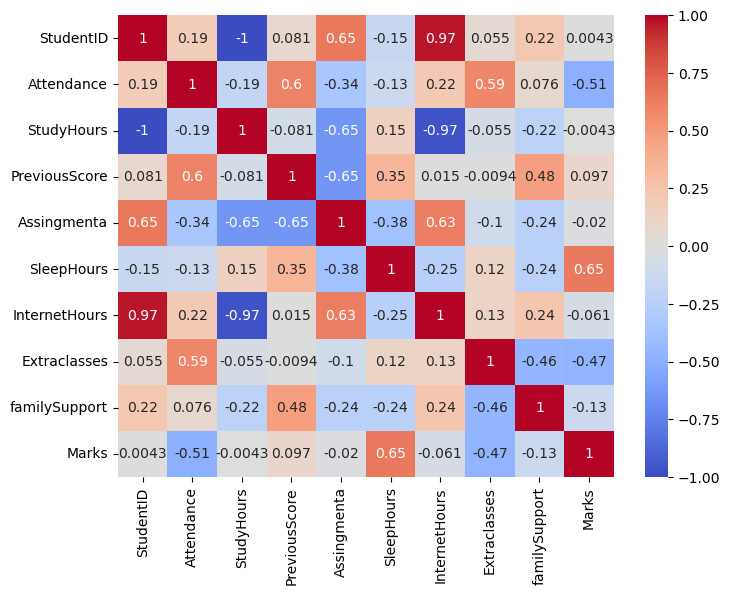

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

## Select Feature and Target

In [14]:
x=df.drop("Marks",axis=1)
y=df["Marks"]

## split the dataset

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)

# training the model 

In [17]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# making predictions 

In [18]:
predictions=model.predict(x_test)

## Evaluate the model

In [19]:
print("r2 Score:",r2_score(y_test,predictions))
print("MSE:",mean_squared_error(y_test,predictions))

r2 Score: -1.0020667111357127
MSE: 242.25007204742124


## Visualize predictions

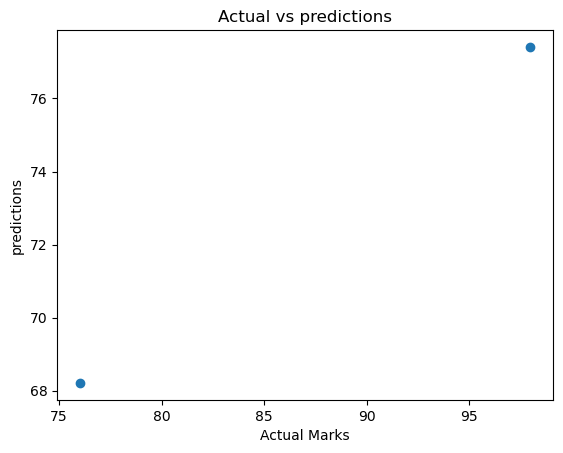

In [20]:
plt.scatter(y_test,predictions)
plt.xlabel("Actual Marks")
plt.ylabel("predictions")
plt.title("Actual vs predictions")
plt.show()

## predict the new model

In [27]:
new_student=[[92,80,28,78,78,66,78,56,78]]
prediction=model.predict(new_student)
print("Predict Marks:",prediction)


Predict Marks: [83.94839821]


In [28]:
import joblib
joblib.dump(model,"student_model.pkl")

['student_model.pkl']

In [29]:
model=joblib.load("student_model.pkl")

In [32]:
df.head()

,StudentID,Attendance,StudyHours,PreviousScore,Assingmenta,SleepHours,InternetHours,Extraclasses,familySupport,Marks
0,101,95,10,90,3,8,2,2,0,90
1,102,80,9,88,4,5,3,0,2,80
2,103,85,8,77,5,6,4,2,0,78
3,104,10,7,66,6,7,4,0,1,98
4,105,75,6,55,7,5,5,2,0,67
